# Visual Pipeline: Person Detection + Visibility Features + Article Aggregation

This notebook implements the visual modality for my project and is designed to align with the textual pipeline through `article_id` and `nationalities_iso3`.

**Process**:
1. Loads article images from `Data/Images/Plain_Images/`
2. Uses the image filename itself to recover `article_id` (the image name is the linked article ID)
3. Uses `Articles2024.csv` to attach article text and metadata through `article_id`
4. Runs a pre-trained COCO person detector with Ultralytics YOLO
5. Extracts person bounding boxes and confidence scores for the `person` class
6. Computes visibility features such as person count, relative size, centrality, close-up/medium/long-shot, and crowd-scene indicators
7. Aggregates these features from person-level -> image-level -> article-level
8. Merges the visual aggregates back to the textual pipeline table where `nationalities_iso3` is stored

Images are mapped to articles in the following format:

`image filename -> article_id -> article metadata/text row`

## Imports

In [2]:
import os
import re
import json
import math
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import cv2

from PIL import Image
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

from deepface import DeepFace
import numpy as np
from typing import Dict

c:\Users\User\miniconda3\envs\FYPenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [ ]:
# PATHS
IMAGE_DIR = Path(r"Data\Images\Plain_Images")

# Article metadata / text table.
# Expected minimum columns:
#   - article_id
#   - url
#   - content
ARTICLE_METADATA_CSV = Path(r"Data\Articles\Articles2024.csv")

# the textual pipeline output keyed by article_id.
TEXTUAL_ARTICLE_CSV = Path(r"Data\Articles\Output\Articles2024_enriched.csv")

# Output directory for the visual pipeline
OUTPUT_DIR = Path(r"Data\Images\Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANNOTATED_DIR = OUTPUT_DIR / "annotated_images"
ANNOTATED_DIR.mkdir(parents=True, exist_ok=True)


# MODEL SETTINGS
YOLO_WEIGHTS = "yolov8m.pt"
CONF_THRESHOLD = 0.25
PERSON_CLASS_ID = 0  # COCO class 0 = person
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

# IMAGE FILENAME -> ARTICLE-ID SETTINGS
STRICT_FILENAME_ARTICLE_ID_MATCH = True
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# ARTICLE METADATA COLUMN SETTINGS
ARTICLE_ID_COL = "article_id"
ARTICLE_URL_COL = "url"
ARTICLE_BODY_COL = "content"
ARTICLE_TITLE_COL = "title"
ARTICLE_SOURCE_COL = "source_name"
ARTICLE_CATEGORY_COL = "categories"
ARTICLE_PUBLISH_DATE_COL = "publish_date"

# HEURISTICS FOR VISIBILITY / SHOT-TYPE
CLOSE_UP_MIN_REL_AREA = 0.25
MEDIUM_SHOT_MIN_REL_AREA = 0.10
CROWD_MIN_PERSONS = 5

# FACE ATTRIBUTES AFTER PERSON DETECTION
RUN_FACE_ATTRIBUTES = True

# Use a lighter backend on my limited hardware
FACE_DETECTOR_BACKEND =  "mtcnn"
FACE_ENFORCE_DETECTION = False
FACE_ALIGN = True

# Filter for attributes to be extracted from detected faces
FACE_ACTIONS = ["race"]

# Face thresholds
FACE_MIN_CONFIDENCE = 0.80
FACE_MIN_RELATIVE_AREA = 0.02
FACE_MIN_CENTER_X_RATIO = 0.15
FACE_MAX_CENTER_X_RATIO = 0.85
FACE_MAX_CENTER_Y_RATIO = 0.55
FACE_AMBIGUITY_MARGIN = 1.10
FACE_SEARCH_UPPER_RATIO = 0.60
FACE_SEARCH_SIDE_MARGIN = 0.10


# Face fields to show in annotations
SHOW_FACE_FIELDS = [
    "face_confidence",
    "face_race"
]

Using device: cuda


## Helper functions

In [ ]:
# Loads the article-level textual pipeline output
def load_textual_article_df(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"Textual CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)

    if "article_id" not in df.columns:
        raise ValueError(f"'article_id' not found in textual CSV columns: {list(df.columns)}")

    return df

# Loads the main article text CSV
def load_article_metadata_df(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"Article metadata CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required = [ARTICLE_ID_COL, ARTICLE_URL_COL, ARTICLE_BODY_COL]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(
            f"Missing required columns in article metadata CSV: {missing}. "
            f"Available columns: {list(df.columns)}"
        )

    df = df.copy()

    # Standardise helper columns used elsewhere in the notebook
    df["article_id"] = pd.to_numeric(df[ARTICLE_ID_COL], errors="coerce").astype("Int64")
    df["article_url"] = df[ARTICLE_URL_COL]
    df["body"] = df[ARTICLE_BODY_COL]

    if ARTICLE_CATEGORY_COL in df.columns:
        df["text_category"] = df[ARTICLE_CATEGORY_COL]
    else:
        df["text_category"] = pd.NA

    return df

# Extracts the linked article_id from an image filename
def infer_article_id_from_filename(filename: str) -> Optional[int]:
    stem = Path(filename).stem.strip()

    matches = re.findall(r"\d+", stem)
    if not matches:
        return None

    try:
        return int(matches[-1])
    except Exception:
        return None

# Builds the core bridge table for the visual pipeline using the image filename
def build_article_image_text_mapping_from_filenames(article_metadata_df: pd.DataFrame, image_dir: Path) -> pd.DataFrame:
    if not image_dir.exists():
        raise FileNotFoundError(f"Image directory not found: {image_dir}")

    image_paths = sorted(
        [
            p for p in image_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]
    )

    rows = []
    for image_path in image_paths:
        image_name = image_path.name
        article_id = infer_article_id_from_filename(image_name)

        if article_id is None and STRICT_FILENAME_ARTICLE_ID_MATCH:
            continue

        rows.append({
            "image_name": image_name,
            "filename": image_name,
            "image_path": str(image_path),
            "article_id": article_id,
        })

    image_df = pd.DataFrame(rows)

    if image_df.empty:
        raise ValueError(
            "No images were discovered in IMAGE_DIR with a supported extension "
            "and a usable article_id in the filename."
        )

    # Make sure article_id is nullable integer before merge
    image_df["article_id"] = pd.to_numeric(image_df["article_id"], errors="coerce").astype("Int64")

    merged = image_df.merge(
        article_metadata_df,
        on="article_id",
        how="left",
        validate="many_to_one"
    )

    # Keep only images whose article_id exists in the article metadata CSV
    merged = merged[merged["article_id"].notna()].copy()
    merged = merged[merged["article_url"].notna()].copy()

    # Add a simple match status column for auditing
    merged["article_match_found"] = merged["body"].notna()

    return merged

# Get image dimensions
def get_image_size(image_path: Path) -> Tuple[int, int]:
    with Image.open(image_path) as img:
        width, height = img.size

    return width, height


# Compute visibility features for a detected bounding box
def compute_bbox_features(xyxy, image_width: int, image_height: int) -> Dict[str, float]:

    x1, y1, x2, y2 = xyxy

    bbox_width = x2 - x1
    bbox_height = y2 - y1

    bbox_area = bbox_width * bbox_height
    image_area = image_width * image_height

    # Relative size of the detected person
    relative_area = bbox_area / image_area if image_area > 0 else np.nan

    # Bounding box centre
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    # Image centre
    icx = image_width / 2
    icy = image_height / 2

    # Euclidean distance from image centre
    centre_distance = np.sqrt((cx - icx) ** 2 + (cy - icy) ** 2)

    # Maximum possible distance (corner of image)
    max_distance = np.sqrt(icx ** 2 + icy ** 2)

    centrality = 1 - (centre_distance / max_distance) if max_distance > 0 else np.nan

    # Simple shot classification
    if relative_area > 0.25:
        shot_type = "close-up"
    elif relative_area > 0.1:
        shot_type = "medium-shot"
    else:
        shot_type = "long-shot"

    return {
        "bbox_x1": float(x1),
        "bbox_y1": float(y1),
        "bbox_x2": float(x2),
        "bbox_y2": float(y2),
        "bbox_width": float(bbox_width),
        "bbox_height": float(bbox_height),
        "bbox_area": float(bbox_area),
        "relative_area": float(relative_area),
        "bbox_center_x": float(cx),
        "bbox_center_y": float(cy),
        "centrality": float(centrality),
        "shot_type": shot_type
    }


def clip_bbox_to_image(x1, y1, x2, y2, width, height):
    x1 = max(0, min(int(x1), width - 1))
    y1 = max(0, min(int(y1), height - 1))
    x2 = max(0, min(int(x2), width - 1))
    y2 = max(0, min(int(y2), height - 1))
    return x1, y1, x2, y2

# Expands a person bbox slightly so a face near the edge is less likely to be cut off
def expand_bbox(x1, y1, x2, y2, width, height, scale=0.10):
    bw = x2 - x1
    bh = y2 - y1
    pad_x = int(bw * scale)
    pad_y = int(bh * scale)
    nx1 = max(0, x1 - pad_x)
    ny1 = max(0, y1 - pad_y)
    nx2 = min(width - 1, x2 + pad_x)
    ny2 = min(height - 1, y2 + pad_y)
    return nx1, ny1, nx2, ny2

def compute_blur_score(image_bgr: np.ndarray) -> float:
    # Higher variance usually means a sharper crop.
    if image_bgr is None or image_bgr.size == 0:
        return np.nan
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def compute_brightness_score(image_bgr: np.ndarray) -> float:
    if image_bgr is None or image_bgr.size == 0:
        return np.nan
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return float(gray.mean())


# Runs face detection + non-sensitive face attribute estimation inside one person detection
def estimate_face_attributes_from_person_crop(
    full_image_bgr,
    person_bbox,
    detector_backend=FACE_DETECTOR_BACKEND,
    actions=FACE_ACTIONS,
    enforce_detection=FACE_ENFORCE_DETECTION,
    align=FACE_ALIGN,
):

    img_h, img_w = full_image_bgr.shape[:2]

    x1, y1, x2, y2 = person_bbox
    x1, y1, x2, y2 = clip_bbox_to_image(x1, y1, x2, y2, img_w, img_h)
    x1, y1, x2, y2 = expand_bbox(x1, y1, x2, y2, img_w, img_h, scale=0.10)

    empty_result = {
        "face_found": 0,
        "face_confidence": np.nan,
        "face_x1": np.nan,
        "face_y1": np.nan,
        "face_x2": np.nan,
        "face_y2": np.nan,
        "face_width": np.nan,
        "face_height": np.nan,
        "face_area": np.nan,
        "face_race": None,
    }

    if x2 <= x1 or y2 <= y1:
        return empty_result

    person_crop = full_image_bgr[y1:y2, x1:x2]
    if person_crop.size == 0:
        return empty_result

    try:
        result = DeepFace.analyze(
            img_path=person_crop,
            actions=actions,
            detector_backend=detector_backend, 
            enforce_detection=enforce_detection,
            align=align,
            silent=True,
        )

        if isinstance(result, list):
            result = result[0]

        region = result.get("region", {}) or {}
        fx = int(region.get("x", 0))
        fy = int(region.get("y", 0))
        fw = int(region.get("w", 0))
        fh = int(region.get("h", 0))

        face_x1 = x1 + fx
        face_y1 = y1 + fy
        face_x2 = face_x1 + fw
        face_y2 = face_y1 + fh

        person_area = max(1.0, float((x2 - x1) * (y2 - y1)))
        face_area = max(0.0, float(fw * fh))

        # Crop just the face for simple quality flags.
        face_crop = None
        if fw > 0 and fh > 0:
            rx1, ry1, rx2, ry2 = clip_bbox_to_image(face_x1, face_y1, face_x2, face_y2, img_w, img_h)
            if rx2 > rx1 and ry2 > ry1:
                face_crop = full_image_bgr[ry1:ry2, rx1:rx2]

        blur_score = compute_blur_score(face_crop) if face_crop is not None else np.nan
        brightness = compute_brightness_score(face_crop) if face_crop is not None else np.nan
        is_blurry = float(blur_score < 80.0) if pd.notna(blur_score) else np.nan
        is_dark = float(brightness < 60.0) if pd.notna(brightness) else np.nan

        return {
            "face_found": 1 if fw > 0 and fh > 0 else 0,
            "face_confidence": float(result.get("face_confidence", np.nan)) if result.get("face_confidence", None) is not None else np.nan,
            "face_x1": face_x1 if fw > 0 else np.nan,
            "face_y1": face_y1 if fh > 0 else np.nan,
            "face_x2": face_x2 if fw > 0 else np.nan,
            "face_y2": face_y2 if fh > 0 else np.nan,
            "face_width": float(fw) if fw > 0 else np.nan,
            "face_height": float(fh) if fh > 0 else np.nan,
            "face_area": face_area if face_area > 0 else np.nan,
            "face_race": result.get("dominant_race"),
            "face_error": None,   
        }
    except Exception as e:
        empty_result["face_error"] = str(e)
        return empty_result


## Load detector

In [5]:
# Load the pre-trained COCO detection model.
# Ultralytics downloads the weights automatically the first time if needed.
model = YOLO(YOLO_WEIGHTS)
model.to(DEVICE)

print(f"Using device: {DEVICE}")
print(f"Loaded model: {YOLO_WEIGHTS}")

Using device: cuda
Loaded model: yolov8m.pt


##  Build the image <-> article <-> text bridge table

In [ ]:
# load article data
article_text_df = load_article_metadata_df(ARTICLE_METADATA_CSV)

# build the core bridge table between modalities
article_image_text_df = build_article_image_text_mapping_from_filenames(
    article_metadata_df=article_text_df,
    image_dir=IMAGE_DIR
)

mapping_output_path = OUTPUT_DIR / "article_image_text_mapping.csv"
article_image_text_df.to_csv(mapping_output_path, index=False)

print(f"Saved: {mapping_output_path}")
print(f"Mapped images with existing files: {len(article_image_text_df)}")
print(f"Unique mapped articles: {article_image_text_df['article_id'].nunique(dropna=True)}")

Saved: Data\Images\Output\article_image_text_mapping.csv
Mapped images with existing files: 16342
Unique mapped articles: 16342


## Person Detection

In [ ]:
# Runs YOLO on one image and returns one record per detected person
def detect_persons_in_image(
    image_path: Path,
    article_id: Optional[int],
    model: YOLO,
    conf_threshold: float = 0.25,
    person_class_id: int = 0,
    image_name: Optional[str] = None,
    article_url: Optional[str] = None,
    text_category: Optional[str] = None,
    body: Optional[str] = None,
    title: Optional[str] = None,
    source_name: Optional[str] = None,
    publish_date: Optional[str] = None,
) -> pd.DataFrame:
    
    image = cv2.imread(str(image_path))
    if image is None:
        return pd.DataFrame()

    image_height, image_width = image.shape[:2]
    image_area = float(image_width * image_height)

    results = model.predict(
        source=image,
        conf=conf_threshold,
        verbose=False,
        device=DEVICE
    )

    rows = []
    detection_id = 0

    for r in results:
        if r.boxes is None:
            continue

        for box in r.boxes:
            cls_id = int(box.cls.item())
            if cls_id != person_class_id:
                continue

            conf = float(box.conf.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            x1, y1, x2, y2 = clip_bbox_to_image(
                x1, y1, x2, y2, image_width, image_height
            )

            bbox_w = max(0, x2 - x1)
            bbox_h = max(0, y2 - y1)
            bbox_area = float(bbox_w * bbox_h)
            relative_area = bbox_area / image_area if image_area > 0 else 0.0

            bbox_cx = (x1 + x2) / 2.0
            bbox_cy = (y1 + y2) / 2.0
            img_cx = image_width / 2.0
            img_cy = image_height / 2.0

            dist = math.sqrt((bbox_cx - img_cx) ** 2 + (bbox_cy - img_cy) ** 2)
            max_dist = math.sqrt(img_cx ** 2 + img_cy ** 2)
            centrality = 1.0 - (dist / max_dist if max_dist > 0 else 0.0)

            if relative_area >= 0.20:
                shot_type = "close_up"
            elif relative_area >= 0.05:
                shot_type = "medium_shot"
            else:
                shot_type = "long_shot"

            visibility_score = (0.6 * relative_area) + (0.4 * centrality) # Emphasis on size

            rows.append({
                "article_id": article_id,
                "article_url": article_url,
                "image_name": image_name if image_name is not None else image_path.name,
                "filename": image_path.name,
                "image_path": str(image_path),
                "image_width": image_width,
                "image_height": image_height,
                "image_area": image_area,
                "person_instance_id": f"{image_path.stem}_p{detection_id}",
                "bbox_x1": x1,
                "bbox_y1": y1,
                "bbox_x2": x2,
                "bbox_y2": y2,
                "bbox_width": bbox_w,
                "bbox_height": bbox_h,
                "bbox_area": bbox_area,
                "confidence": conf,
                "relative_area": relative_area,
                "centrality": centrality,
                "visibility_score": visibility_score,
                "shot_type": shot_type,
                "text_category": text_category,
                "body": body,
                "title": title,
                "source_name": source_name,
                "publish_date": publish_date,
            })

            detection_id += 1

    return pd.DataFrame(rows)


## Run Person Detection

In [9]:
person_dfs = []

for row in tqdm(
    article_image_text_df.itertuples(index=False),
    total=len(article_image_text_df),
    desc="Running person detection"
):
    image_path = Path(row.image_path)

    detections_df = detect_persons_in_image(
        image_path=image_path,
        article_id=getattr(row, "article_id", None),
        model=model,
        conf_threshold=CONF_THRESHOLD,
        person_class_id=PERSON_CLASS_ID,
        image_name=getattr(row, "image_name", image_path.name),
        article_url=getattr(row, "article_url", None),
        body=getattr(row, "body", None),
        text_category=getattr(row, "text_category", None),
        title=getattr(row, "title", None),
        source_name=getattr(row, "source_name", None),
        publish_date=getattr(row, "publish_date", None),
    )

    if detections_df is not None and not detections_df.empty:
        person_dfs.append(detections_df)

person_df = pd.concat(person_dfs, ignore_index=True) if person_dfs else pd.DataFrame()

person_csv_path = OUTPUT_DIR / "person_detections.csv"
person_df.to_csv(person_csv_path, index=False)

print(f"Saved: {person_csv_path}")
print(person_df.shape)
person_df.head()

Running person detection: 100%|██████████| 16342/16342 [07:28<00:00, 36.43it/s]


Saved: Data\Images\Output\person_detections.csv
(57905, 26)


,article_id,article_url,image_name,filename,image_path,image_width,image_height,image_area,person_instance_id,bbox_x1,...,confidence,relative_area,centrality,visibility_score,shot_type,text_category,body,title,source_name,publish_date
0,100,https://www.maltatoday.com.mt/news/data_and_su...,100.png,100.png,Data\Images\Plain_Images\100.png,3000,1688,5064000.0,100_p0,1626,...,0.960496,0.388293,0.536432,0.447548,close_up,{},"James Debono, 2024-11-17, SUMMARY\nThe Labour ...",Parties running neck and neck as budget bounce...,Malta Today,"None 31.8% "" GOV. PERFORMANCE: 2.7 out of 5"""
1,100,https://www.maltatoday.com.mt/news/data_and_su...,100.png,100.png,Data\Images\Plain_Images\100.png,3000,1688,5064000.0,100_p1,69,...,0.958976,0.417967,0.592590,0.487816,close_up,{},"James Debono, 2024-11-17, SUMMARY\nThe Labour ...",Parties running neck and neck as budget bounce...,Malta Today,"None 31.8% "" GOV. PERFORMANCE: 2.7 out of 5"""
2,10000,https://timesofmalta.com/article/government-fo...,10000.jpg,10000.jpg,Data\Images\Plain_Images\10000.jpg,1620,1080,1749600.0,10000_p0,976,...,0.913916,0.252455,0.465589,0.337709,close_up,{},The government is united and focused on improv...,Government is focused on improving peoples lives,Times of Malta,28/01/2024
3,10000,https://timesofmalta.com/article/government-fo...,10000.jpg,10000.jpg,Data\Images\Plain_Images\10000.jpg,1620,1080,1749600.0,10000_p1,729,...,0.887843,0.152682,0.799612,0.411454,medium_shot,{},The government is united and focused on improv...,Government is focused on improving peoples lives,Times of Malta,28/01/2024
4,10000,https://timesofmalta.com/article/government-fo...,10000.jpg,10000.jpg,Data\Images\Plain_Images\10000.jpg,1620,1080,1749600.0,10000_p2,521,...,0.843377,0.137449,0.709524,0.366279,medium_shot,{},The government is united and focused on improv...,Government is focused on improving peoples lives,Times of Malta,28/01/2024


## Face Detection

### Face detection functions

In [ ]:
def build_empty_face_result(person_instance_id):
    return {
        "person_instance_id": person_instance_id,
        "face_found": 0,
        "face_confidence": np.nan,
        "face_x1": np.nan,
        "face_y1": np.nan,
        "face_x2": np.nan,
        "face_y2": np.nan,
        "face_width": np.nan,
        "face_height": np.nan,
        "face_area": np.nan,
        "face_relative_area_within_person": np.nan,
        "face_blur_score": np.nan,
        "face_brightness": np.nan,
        "face_is_blurry": np.nan,
        "face_is_dark": np.nan,
        "face_race": np.nan,
        "face_error": None,
    }

# Detect faces inside one detected person box, keep only the best face, and reject weak / ambiguous matches
def estimate_face_attributes_for_detection(row) -> dict:
    person_instance_id = row["person_instance_id"]
    image_path = row["image_path"]

    empty_result = {
        "person_instance_id": person_instance_id,
        "face_found": 0,
        "face_confidence": np.nan,
        "face_x1": np.nan,
        "face_y1": np.nan,
        "face_x2": np.nan,
        "face_y2": np.nan,
        "face_width": np.nan,
        "face_height": np.nan,
        "face_area": np.nan,
        "face_relative_area_within_person": np.nan,
        "face_blur_score": np.nan,
        "face_brightness": np.nan,
        "face_is_blurry": np.nan,
        "face_is_dark": np.nan,
        "face_race": np.nan,
        "face_error": None,
        "n_faces_in_person_crop": 0,
        "selected_face_rank": np.nan,
        "selected_face_rank_score": np.nan,
    }

    image = cv2.imread(str(image_path))
    if image is None:
        empty_result["face_error"] = "image_not_readable"
        return empty_result

    img_h, img_w = image.shape[:2]

    x1 = int(row["bbox_x1"])
    y1 = int(row["bbox_y1"])
    x2 = int(row["bbox_x2"])
    y2 = int(row["bbox_y2"])

    x1, y1, x2, y2 = clip_bbox_to_image(x1, y1, x2, y2, img_w, img_h)
    x1, y1, x2, y2 = expand_bbox(x1, y1, x2, y2, img_w, img_h, scale=0.10)

    if x2 <= x1 or y2 <= y1:
        empty_result["face_error"] = "invalid_person_bbox"
        return empty_result

    person_crop = image[y1:y2, x1:x2]
    if person_crop.size == 0:
        empty_result["face_error"] = "empty_person_crop"
        return empty_result

    person_h, person_w = person_crop.shape[:2]
    person_area = max(1.0, float(person_w * person_h))

    search_y1 = 0
    search_y2 = person_h
    search_x1 = 0
    search_x2 = person_w

    if search_x2 <= search_x1 or search_y2 <= search_y1:
        empty_result["face_error"] = "invalid_search_region"
        return empty_result

    search_crop = person_crop
    search_h, search_w = search_crop.shape[:2]

    try:
        face_objs = DeepFace.extract_faces(
            img_path=search_crop,
            detector_backend=FACE_DETECTOR_BACKEND,
            enforce_detection=FACE_ENFORCE_DETECTION,
            align=FACE_ALIGN,
        )

        if not face_objs:
            empty_result["face_error"] = "no_face_detected"
            return empty_result

        candidates = []

        for i, obj in enumerate(face_objs, start=1):
            region = obj.get("facial_area", {}) or obj.get("region", {}) or {}

            fx = int(region.get("x", 0))
            fy = int(region.get("y", 0))
            fw = int(region.get("w", 0))
            fh = int(region.get("h", 0))

            if fw <= 0 or fh <= 0:
                continue

            face_area = float(fw * fh)
            det_conf = obj.get("confidence", np.nan)
            det_conf = float(det_conf) if det_conf is not None else np.nan

            # Face center relative to person crop, not just search crop
            face_cx_person = search_x1 + fx + (fw / 2.0)
            face_cy_person = search_y1 + fy + (fh / 2.0)

            face_center_x_ratio = face_cx_person / max(1.0, person_w)
            face_center_y_ratio = face_cy_person / max(1.0, person_h)
            face_rel_area = face_area / person_area

            # Ranking terms
            horizontal_offset = abs(face_center_x_ratio - 0.50)
            horizontal_score = 1.0 - min(1.0, horizontal_offset / 0.50)

            vertical_score = 1.0 - min(1.0, face_center_y_ratio / max(1e-6, FACE_MAX_CENTER_Y_RATIO))
            vertical_score = max(0.0, vertical_score)

            size_score = min(1.0, face_rel_area / max(FACE_MIN_RELATIVE_AREA, 1e-6))
            conf_score = det_conf if pd.notna(det_conf) else 0.0

            rank_score = (
                0.40 * conf_score +
                0.25 * size_score +
                0.20 * horizontal_score +
                0.15 * vertical_score
            )

            candidates.append({
                "rank_index": i,
                "rank_score": rank_score,
                "det_conf": det_conf,
                "fx": fx,
                "fy": fy,
                "fw": fw,
                "fh": fh,
                "face_area": face_area,
                "face_rel_area": face_rel_area,
                "face_center_x_ratio": face_center_x_ratio,
                "face_center_y_ratio": face_center_y_ratio,
            })

        if not candidates:
            empty_result["face_error"] = "faces_detected_but_invalid_regions"
            return empty_result

        candidates = sorted(candidates, key=lambda d: d["rank_score"], reverse=True)
        best = candidates[0]

        empty_result["n_faces_in_person_crop"] = len(candidates)

        # Ambiguity rejection
        if len(candidates) > 1:
            score1 = candidates[0]["rank_score"]
            score2 = candidates[1]["rank_score"]
            if score1 < FACE_AMBIGUITY_MARGIN * score2:
                empty_result["face_error"] = "ambiguous_multiple_faces"
                return empty_result

        # Threshold 1: face confidence
        if pd.isna(best["det_conf"]) or best["det_conf"] < FACE_MIN_CONFIDENCE:
            empty_result["face_error"] = "low_face_confidence"
            return empty_result

        # Threshold 2: relative face size
        if best["face_rel_area"] < FACE_MIN_RELATIVE_AREA:
            empty_result["face_error"] = "face_too_small_relative_to_person"
            return empty_result
        
        # Threshold 3: expected position in person box
        if not (FACE_MIN_CENTER_X_RATIO <= best["face_center_x_ratio"] <= FACE_MAX_CENTER_X_RATIO):
            empty_result["face_error"] = "face_not_centered_in_person_box"
            return empty_result

        fx = best["fx"]
        fy = best["fy"]
        fw = best["fw"]
        fh = best["fh"]

        # Convert search-crop coordinates back to full image coordinates
        face_x1 = x1 + search_x1 + fx
        face_y1 = y1 + search_y1 + fy
        face_x2 = face_x1 + fw
        face_y2 = face_y1 + fh

        rx1, ry1, rx2, ry2 = clip_bbox_to_image(face_x1, face_y1, face_x2, face_y2, img_w, img_h)
        if rx2 <= rx1 or ry2 <= ry1:
            empty_result["face_error"] = "selected_face_out_of_bounds"
            return empty_result

        face_crop = image[ry1:ry2, rx1:rx2]
        if face_crop is None or face_crop.size == 0:
            empty_result["face_error"] = "selected_face_crop_empty"
            return empty_result

        blur_score = compute_blur_score(face_crop)
        brightness = compute_brightness_score(face_crop)
        is_blurry = float(blur_score < 80.0) if pd.notna(blur_score) else np.nan
        is_dark = float(brightness < 60.0) if pd.notna(brightness) else np.nan

        # Run deepface attribute analysis on the selected face crop
        analysis = DeepFace.analyze(
            img_path=face_crop,
            actions=FACE_ACTIONS,
            detector_backend="skip",
            enforce_detection=False,
            align=False,
            silent=True,
        )

        if isinstance(analysis, list):
            analysis = analysis[0]


        return {
            "person_instance_id": person_instance_id,
            "face_found": 1,
            "face_confidence": best["det_conf"],
            "face_x1": face_x1,
            "face_y1": face_y1,
            "face_x2": face_x2,
            "face_y2": face_y2,
            "face_width": float(fw),
            "face_height": float(fh),
            "face_area": float(best["face_area"]),
            "face_relative_area_within_person": float(best["face_rel_area"]),
            "face_blur_score": blur_score,
            "face_brightness": brightness,
            "face_is_blurry": is_blurry,
            "face_is_dark": is_dark,
            "face_race": analysis.get("dominant_race"),
            "face_error": None,
            "n_faces_in_person_crop": len(candidates),
            "selected_face_rank": 1,
            "selected_face_rank_score": best["rank_score"],
        }

    except Exception as e:
        empty_result["face_error"] = repr(e)
        return empty_result


### Prepare only the rows to analyze

In [ ]:
# Filter to stronger person detections before running DeepFace, due to limitations of hardware and time.
face_candidates_df = person_df[
    (person_df["confidence"] >= 0.50) &
    (person_df["shot_type"].isin(["close_up", "medium_shot"]))
].copy()

print("Total person detections:", len(person_df))
print("Face candidates:", len(face_candidates_df))

Total person detections: 57905
Face candidates: 22809


### Run face detection and attribute estimation for "Race"

In [ ]:
face_rows = []

for row in tqdm(
    face_candidates_df.to_dict(orient="records"),
    total=len(face_candidates_df),
    desc="Running DeepFace on person detections"
):
    face_rows.append(estimate_face_attributes_for_detection(row))

face_df = pd.DataFrame(face_rows)

Running DeepFace on person detections:   0%|          | 0/22809 [00:00<?, ?it/s]

26-04-02 12:49:50 - 🔗 race_model_single_batch.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5 to C:\Users\User\.deepface\weights\race_model_single_batch.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5
To: C:\Users\User\.deepface\weights\race_model_single_batch.h5
100%|██████████| 537M/537M [00:18<00:00, 29.6MB/s]
Running DeepFace on person detections: 100%|██████████| 22809/22809 [1:43:45<00:00,  3.66it/s]  


### Merge face outputs back into person_df

In [14]:
person_with_faces_df = person_df.merge(
    face_df,
    on="person_instance_id",
    how="left"
)

merged_csv_path = OUTPUT_DIR / "person_detections_with_face_attributes.csv"
person_with_faces_df.to_csv(merged_csv_path, index=False)

print(f"Saved: {merged_csv_path}")
print(person_with_faces_df.shape)
person_with_faces_df.head()

Saved: Data\Images\Output\person_detections_with_face_attributes.csv
(57905, 45)


,article_id,article_url,image_name,filename,image_path,image_width,image_height,image_area,person_instance_id,bbox_x1,...,face_relative_area_within_person,face_blur_score,face_brightness,face_is_blurry,face_is_dark,face_race,face_error,n_faces_in_person_crop,selected_face_rank,selected_face_rank_score
0,100,https://www.maltatoday.com.mt/news/data_and_su...,100.png,100.png,Data\Images\Plain_Images\100.png,3000,1688,5064000.0,100_p0,1626,...,0.047765,516.889969,105.795742,0.0,0.0,white,NaN,1.0,1.0,0.926138
1,100,https://www.maltatoday.com.mt/news/data_and_su...,100.png,100.png,Data\Images\Plain_Images\100.png,3000,1688,5064000.0,100_p1,69,...,0.046297,23.730660,141.377438,1.0,0.0,white,NaN,1.0,1.0,0.902443
2,10000,https://timesofmalta.com/article/government-fo...,10000.jpg,10000.jpg,Data\Images\Plain_Images\10000.jpg,1620,1080,1749600.0,10000_p0,976,...,NaN,NaN,NaN,NaN,NaN,NaN,low_face_confidence,1.0,NaN,NaN
3,10000,https://timesofmalta.com/article/government-fo...,10000.jpg,10000.jpg,Data\Images\Plain_Images\10000.jpg,1620,1080,1749600.0,10000_p1,729,...,0.177200,635.515840,153.699944,0.0,0.0,middle eastern,NaN,1.0,1.0,0.771864
4,10000,https://timesofmalta.com/article/government-fo...,10000.jpg,10000.jpg,Data\Images\Plain_Images\10000.jpg,1620,1080,1749600.0,10000_p2,521,...,NaN,NaN,NaN,NaN,NaN,NaN,face_too_small_relative_to_person,1.0,NaN,NaN


# ANNOTATIONS

In [ ]:
merged_csv_path = OUTPUT_DIR / "person_detections_with_face_attributes.csv"
annot_df = pd.read_csv(merged_csv_path)

In [ ]:
def format_face_label(row, show_fields):
    parts = []

    for col in show_fields:
        if col not in row.index:
            continue

        val = row[col]
        if pd.isna(val):
            continue

        if col == "face_confidence":
            parts.append(f"conf:{float(val):.2f}")
        elif col == "face_blur_score":
            parts.append(f"blur:{float(val):.1f}")
        elif col == "face_brightness":
            parts.append(f"bright:{float(val):.1f}")
        elif col in ["face_is_blurry", "face_is_dark"]:
            parts.append(f"{col.replace('face_', '')}:{int(float(val))}")
        else:
            parts.append(f"{col}:{val}")

    return " | ".join(parts)

def annotate_image_group(image_path, group_df, output_path, show_face_fields):
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Could not read image: {image_path}")
        return

    font = cv2.FONT_HERSHEY_SIMPLEX

    # Bigger styling
    person_box_thickness = 4
    face_box_thickness = 4

    person_font_scale = 0.9
    face_font_scale = 1.2

    person_text_thickness = 3
    face_text_thickness = 4

    for _, row in group_df.iterrows():
        # Person box in green
        x1 = int(row["bbox_x1"])
        y1 = int(row["bbox_y1"])
        x2 = int(row["bbox_x2"])
        y2 = int(row["bbox_y2"])

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), person_box_thickness)

        person_text = (
            f"{row['person_instance_id']} | "
            f"conf:{float(row['confidence']):.2f} | "
            f"{row['shot_type']}"
        )
        cv2.putText(
            image,
            person_text,
            (x1, max(35, y1 - 15)),   # move text a bit higher
            font,
            person_font_scale,
            (0, 255, 0),
            person_text_thickness,
            cv2.LINE_AA
        )

        # Face box in blue, only if a face was found
        face_found = row["face_found"] if "face_found" in row.index else 0
        has_face_box = (
            pd.notna(row.get("face_x1")) and
            pd.notna(row.get("face_y1")) and
            pd.notna(row.get("face_x2")) and
            pd.notna(row.get("face_y2"))
        )

        if pd.notna(face_found) and int(face_found) == 1 and has_face_box:
            fx1 = int(row["face_x1"])
            fy1 = int(row["face_y1"])
            fx2 = int(row["face_x2"])
            fy2 = int(row["face_y2"])

            cv2.rectangle(image, (fx1, fy1), (fx2, fy2), (255, 0, 0), face_box_thickness)

            face_text = format_face_label(row, show_face_fields)
            if face_text:
                cv2.putText(
                    image,
                    face_text,
                    (fx1, max(40, fy1 - 15)),   # move text a bit higher
                    font,
                    face_font_scale,
                    (255, 0, 0),
                    face_text_thickness,
                    cv2.LINE_AA
                )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), image)

In [17]:
annot_face_df = annot_df[annot_df["face_found"] == 1].copy()

for image_path_str, group in annot_face_df.groupby("image_path", dropna=False):
    image_path = Path(image_path_str)
    out_path = ANNOTATED_DIR / image_path.name
    annotate_image_group(image_path, group, out_path, SHOW_FACE_FIELDS)

print(f"Saved all annotated images to: {ANNOTATED_DIR}")

Saved all annotated images to: Data\Images\Output\annotated_images_with_faces


# GENERAL ANALYSIS

In [ ]:
faces_df = pd.read_csv("Data/Images/Output/person_detections_with_face_attributes.csv")

# Total number of persons extracted
total_persons = len(faces_df)

# Total number of persons where a face was found
total_faces_found = faces_df["face_found"].eq(1).sum()

summary_table = pd.DataFrame({
    "visual_feature": ["Persons extracted", "Faces extracted"],
    "total": [total_persons, total_faces_found]
})

print(summary_table)

      visual_feature  total
0  Persons extracted  57905
1    Faces extracted  14278


In [7]:
race_counts = (
    faces_df["face_race"]
    .dropna()
    .value_counts()
    .reset_index()
)

race_counts.columns = ["approximated_race", "count"]

print(race_counts)

  approximated_race  count
0             white  10058
1    middle eastern   2393
2             asian    707
3   latino hispanic    673
4             black    358
5            indian     89


Total accepted faces: 14278

Estimated race counts:
face_race_clean
White              10058
Middle Eastern      2393
Asian                707
Latino Hispanic      673
Black                358
Indian                89
Name: count, dtype: int64

Shot type counts:
shot_type_clean
Close-Up       7395
Medium-Shot    6883
Name: count, dtype: int64


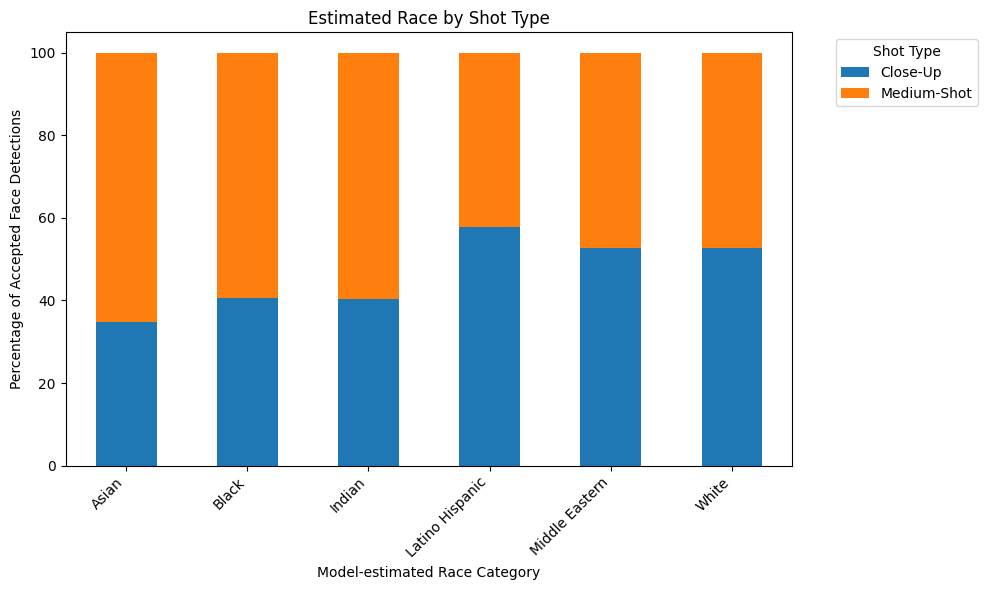

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load visual pipeline output
df = pd.read_csv("Data/Images/Output/person_detections_with_face_attributes.csv")

# Keep only accepted face detections
faces_df = df[
    (df["face_found"] == 1) &
    (df["face_race"].notna())
].copy()

# clean labels for better plots
faces_df["face_race_clean"] = (
    faces_df["face_race"]
    .str.replace("_", " ")
    .str.title()
)

faces_df["shot_type_clean"] = (
    faces_df["shot_type"]
    .str.replace("_", "-")
    .str.title()
)

# Check available classes
print("Total accepted faces:", len(faces_df))
print("\nEstimated race counts:")
print(faces_df["face_race_clean"].value_counts())

print("\nShot type counts:")
print(faces_df["shot_type_clean"].value_counts())


# Raw count table
race_shot_counts = pd.crosstab(
    faces_df["face_race_clean"],
    faces_df["shot_type_clean"]
)

# Percentage table by estimated race
race_shot_percentages = pd.crosstab(
    faces_df["face_race_clean"],
    faces_df["shot_type_clean"],
    normalize="index"
) * 100

race_shot_percentages = race_shot_percentages.round(1)

# Stacked percentage bar chart
ax = race_shot_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Estimated Race by Shot Type")
plt.xlabel("Model-estimated Race Category")
plt.ylabel("Percentage of Accepted Face Detections")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Shot Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("visual_race_by_shot_type_percentage.png", dpi=300)
plt.show()

In [ ]:
df = pd.read_csv("Data/Images/Output/person_detections_with_face_attributes.csv")

# Keep only accepted face detections with an estimated race category
faces_df = df[
    (df["face_found"] == 1) &
    (df["face_race"].notna())
].copy()

# Clean labels
faces_df["face_race_clean"] = (
    faces_df["face_race"]
    .str.replace("_", " ")
    .str.title()
)

# Make sure flags are numeric
faces_df["face_is_blurry"] = pd.to_numeric(faces_df["face_is_blurry"], errors="coerce")
faces_df["face_is_dark"] = pd.to_numeric(faces_df["face_is_dark"], errors="coerce")

In [13]:
quality_summary = (
    faces_df
    .groupby("face_race_clean")
    .agg(
        total_faces=("face_race_clean", "size"),
        mean_visibility_score=("visibility_score", "mean"),
        mean_relative_person_area=("relative_area", "mean"),
        mean_face_confidence=("face_confidence", "mean"),
        mean_blur_score=("face_blur_score", "mean"),
        mean_brightness=("face_brightness", "mean"),
        blurry_faces=("face_is_blurry", "sum"),
        dark_faces=("face_is_dark", "sum")
    )
    .reset_index()
)

quality_summary["blurry_face_rate_%"] = (
    quality_summary["blurry_faces"] / quality_summary["total_faces"] * 100
)

quality_summary["dark_face_rate_%"] = (
    quality_summary["dark_faces"] / quality_summary["total_faces"] * 100
)

quality_summary = quality_summary.round({
    "mean_visibility_score": 3,
    "mean_relative_person_area": 3,
    "mean_face_confidence": 3,
    "mean_blur_score": 1,
    "mean_brightness": 1,
    "blurry_face_rate_%": 2,
    "dark_face_rate_%": 2
})

In [ ]:
table = quality_summary[
    [
        "face_race_clean",
        "total_faces",
        "mean_visibility_score",
        "mean_brightness",
        "blurry_face_rate_%",
        "dark_face_rate_%"
    ]
].copy()

table = table.rename(columns={
    "face_race_clean": "Model-estimated race",
    "total_faces": "Total faces",
    "mean_visibility_score": "Mean visibility score",
    "mean_brightness": "Mean brightness",
    "blurry_face_rate_%": "Blurry face rate (%)",
    "dark_face_rate_%": "Dark face rate (%)"
})

display(table)

,Model-estimated race,Total faces,Mean visibility score,Mean brightness,Blurry face rate (%),Dark face rate (%)
0,Asian,707,0.356,119.2,23.76,2.40
1,Black,358,0.376,96.7,22.35,8.38
2,Indian,89,0.362,101.3,17.98,2.25
3,Latino Hispanic,673,0.435,120.4,24.96,2.38
4,Middle Eastern,2393,0.416,123.4,20.94,1.09
5,White,10058,0.411,129.5,20.59,0.92


In [ ]:
# Load CSV
df = pd.read_csv("Data/Images/Output/person_detections_with_face_attributes.csv")

# Crowding = number of detected persons in the same image
persons_per_image = (
    df.groupby("image_name")["person_instance_id"]
    .count()
    .rename("persons_in_image")
)

df = df.merge(persons_per_image, on="image_name", how="left")

# Off-centre score = 1 - centrality
# Higher value means further away from image centre
df["off_center_score"] = 1 - df["centrality"]
df["off_center_score"] = df["off_center_score"].clip(0, 1)

# Keep only accepted face detections with model-estimated race
faces_df = df[
    (df["face_found"] == 1) &
    (df["face_race"].notna())
].copy()

# Clean race labels
faces_df["face_race_clean"] = (
    faces_df["face_race"]
    .str.replace("_", " ")
    .str.title()
)

# Summary table
crowding_table = (
    faces_df
    .groupby("face_race_clean")
    .agg(
        mean_persons_in_image=("persons_in_image", "mean"),
        mean_off_center_score=("off_center_score", "mean"),
    )
    .reset_index()
)

crowding_table = crowding_table.round({
    "mean_persons_in_image": 2,
    "mean_off_center_score": 3
})

crowding_table = crowding_table.rename(columns={
    "face_race_clean": "Model-estimated Race",
    "mean_persons_in_image": "Mean Persons in Image",
    "mean_off_center_score": "Mean Off-centre Score",
})

display(crowding_table)


,Model-estimated Race,Mean Persons in Image,Mean Off-centre Score
0,Asian,7.34,0.411
1,Black,7.64,0.411
2,Indian,6.36,0.431
3,Latino Hispanic,5.49,0.359
4,Middle Eastern,5.67,0.368
5,White,5.73,0.370


In [ ]:
# Load CSV
df = pd.read_csv("Data/Images/Output/person_detections_with_face_attributes.csv")

# Crowding = number of detected persons in the same image
df["persons_in_image"] = df.groupby("image_name")["person_instance_id"].transform("count")

# Off-centre score = 1 - centrality
# Higher value means further away from image centre
df["off_center_score"] = 1 - df["centrality"]
df["off_center_score"] = df["off_center_score"].clip(0, 1)

# Keep only accepted face detections with model-estimated race
faces_df = df[
    (df["face_found"] == 1) &
    (df["face_race"].notna())
].copy()

# Clean race labels
faces_df["face_race_clean"] = (
    faces_df["face_race"]
    .str.replace("_", " ")
    .str.title()
)

# Ensure quality flags are numeric
faces_df["face_is_blurry"] = pd.to_numeric(faces_df["face_is_blurry"], errors="coerce").fillna(0)
faces_df["face_is_dark"] = pd.to_numeric(faces_df["face_is_dark"], errors="coerce").fillna(0)

# Create final dissertation table directly
visual_portrayal_table = (
    faces_df
    .groupby("face_race_clean")
    .agg(
        total_faces=("face_race_clean", "size"),
        mean_visibility_score=("visibility_score", "mean"),
        mean_brightness=("face_brightness", "mean"),
        blurry_face_rate=("face_is_blurry", lambda x: x.mean() * 100),
        dark_face_rate=("face_is_dark", lambda x: x.mean() * 100),
        mean_persons_in_image=("persons_in_image", "mean"),
        mean_off_center_score=("off_center_score", "mean")
    )
    .reset_index()
)

# Rename columns
visual_portrayal_table = visual_portrayal_table.rename(columns={
    "face_race_clean": "Model-estimated Race",
    "total_faces": "Total Faces",
    "mean_visibility_score": "Mean Visibility Score",
    "mean_brightness": "Mean Brightness",
    "blurry_face_rate": "Blurry Face Rate (%)",
    "dark_face_rate": "Dark Face Rate (%)",
    "mean_persons_in_image": "Mean Persons in Image",
    "mean_off_center_score": "Mean Off-centre Score"
})

# Round values for dissertation table
visual_portrayal_table = visual_portrayal_table.round({
    "Mean Visibility Score": 3,
    "Mean Brightness": 1,
    "Blurry Face Rate (%)": 2,
    "Dark Face Rate (%)": 2,
    "Mean Persons in Image": 2
})

# Display and save
display(visual_portrayal_table)

NameError: name 'pd' is not defined